# Cat Allergy - Bayes' Rule

Hunter says she is itchy. There is a test for Allergy to Cats, but this test is not always right:

    For people that really do have the allergy, the test says "Yes" 80% of the time
    For people that do not have the allergy, the test says "Yes" 10% of the time ("false positive")

If 1% of the population have the allergy, and Hunter's test says "Yes", what are the chances that Hunter really has the allergy?

## Step 1: Define Hypothesis

In [1]:
priors = {
    "allergy": 0.01,
    "not allergy": 0.99
}

## Step 2: Define Likelihoods

In [2]:
test_likelihoods = {
    "allergy": 0.80,
    "not allergy": 0.10
}

In [3]:
from probmodels import bayes_update, explain_update, normalize, simulate_bayes_binary

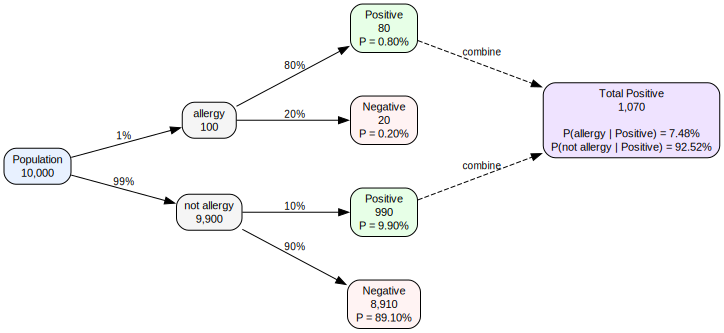

In [4]:
result = explain_update(
    priors,
    test_likelihoods,
    population_size=10_000,
    evidence_name="Positive",
    no_evidence_name="Negative",
    draw_tree=True,
)

result["tree"]

## Step 3: Simulation with Python

In [5]:
from probmodels import simulate_bayes_binary

result = simulate_bayes_binary(
    n = 10_000,
    p_h = 0.01,
    p_e_given_h = 0.80,
    p_e_given_not_h = 0.10,
    hypothesis_name = "Allergy",
    evidence_name="Positive",
    seed=42
)

result["table"]

,Allergy,Not Allergy,Total
Positive,89,994,1083
Not Positive,23,8894,8917
Total,112,9888,10000


In [15]:
import numpy as np

table = result["table"]

p_allergy_given_positive = (
    table.loc["Positive", "Allergy"]
    / table.loc["Positive", "Total"]
)

print(f"P(Allergy | Positive) = {p_allergy_given_positive:.2%}")

P(Allergy | Positive) = 8.22%
